In [1]:
!wget https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/predict+students+dropout+and+academic+success.zip
!wget https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/student+performance.zip

--2025-11-26 21:22:23--  https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/predict+students+dropout+and+academic+success.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/lecture_analytics/main/datasets/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.zip [following]
--2025-11-26 21:22:24--  https://raw.githubusercontent.com/javierherrera1996/lecture_analytics/main/datasets/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 533344 (521K) [application/zip]
Saving to: ‘predict+students+drop

In [2]:
!unzip student+performance.zip
!unzip student.zip

Archive:  student+performance.zip
 extracting: .student.zip_old        
 extracting: student.zip             
Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             


In [3]:
!unzip predict+students+dropout+and+academic+success.zip

Archive:  predict+students+dropout+and+academic+success.zip
 extracting: data.csv                


## Datos
Si quiere conocer mas al detalle los datos mire

student-mat.csv
 ------>https://archive.ics.uci.edu/dataset/320/student+performance

data.csv------>https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

### Regression

In [4]:
import pandas as pd

student = pd.read_csv("student-mat.csv", sep=";")

In [5]:
student.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

## Clasificacion

In [6]:
import pandas as pd
dropout = pd.read_csv("data.csv",sep=";")
dropout

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


**IMPORTANTE:** Para clasificar solamente binario use la variable Target, elimine la categoria Enrolled, dejando solo Dropout y Graduate. Convierte Dropout en 1 y Graduate en 0

---
Use el siguiente codigo :

dropout = data[data["Target"] != "Enrolled"].reset_index(drop=True)

dropout["Target"] = dropout["Target"].map({"Dropout": 1, "Graduate": 0})


In [7]:
# Crear clasificación binaria eliminando la categoría "Enrolled"
dropout = dropout[dropout["Target"] != "Enrolled"].reset_index(drop=True)

# Convertir Dropout a 1 y Graduate a 0
dropout["Target"] = dropout["Target"].map({"Dropout": 1, "Graduate": 0})


dropout["Target"].value_counts()

,count
Target,
0,2209
1,1421


## Modelo de Clasificación

1. Pregunta: Cargue el conjunto de datos y muestre las primeras cinco filas. ¿Qué características puedes observar? La variable objetivo esta balanceada ?

In [8]:
dropout.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


In [11]:
dropout.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance	                     3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification                   

2. Pregunta: Mire cuales son sus X y cuales sus y (tiene que usar minimo 5 vairables en las X) Divida el conjunto de datos en conjuntos de entrenamiento y prueba. ¿Qué proporción considera adecuada para este caso?


In [45]:
# Variable objetivo
y = dropout["Target"]

# Variables independientes (mínimo 5)
X = dropout[[
    "Admission grade",
    "Age at enrollment",
    "Scholarship holder",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]]
# division
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

2 Use un modelo de regresion logistica y un arbol de decision. Para cada uno haga una matrix de confusion y una grafica de ROC AUC

Modelo de regresión logistica

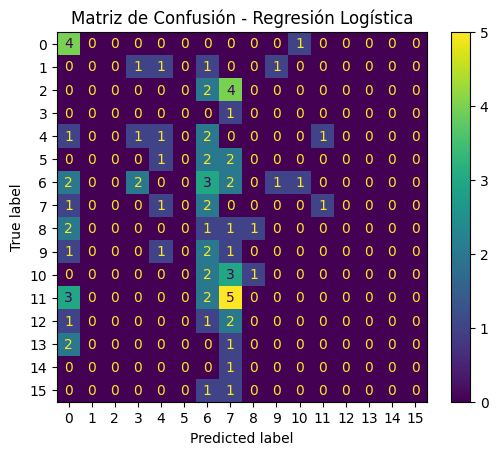

ValueError: multiclass format is not supported

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

 # modelo de regresioón logística
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

# ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Logística (AUC = {roc_auc:.3f})")
plt.show()


Árbol de Decisión

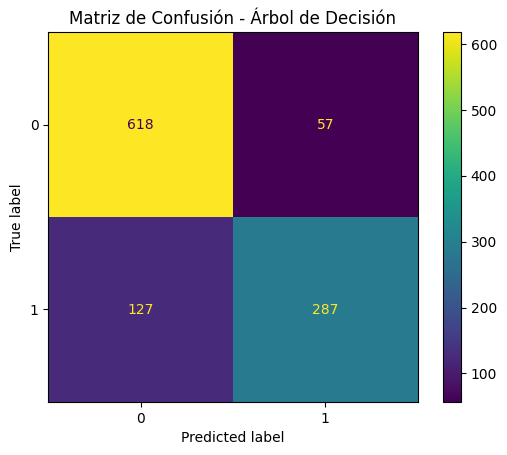

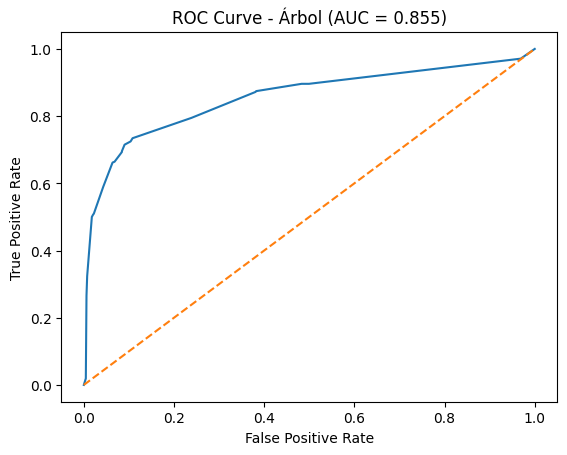

In [20]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

# ROC AUC
fpr_t, tpr_t, thresholds_t = roc_curve(y_test, y_prob_tree)
roc_auc_t = auc(fpr_t, tpr_t)

plt.plot(fpr_t, tpr_t)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Árbol (AUC = {roc_auc_t:.3f})")
plt.show()


## Modelo de Regresion

In [26]:
import pandas as pd

student = pd.read_csv("student-mat.csv", sep=";")

1. Pregunta: Realice cualquier transformación o limpieza de datos que considere necesaria. ¿Por qué es importante preparar los datos antes del modelado?

In [28]:
student.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [29]:
# Revisar valores nulos por columna
student.isnull().sum()


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [30]:
student.dtypes


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [32]:
student.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Es importante preparar los datos antes del modelado porque esto asegura que el algoritmo trabaje con información completa, coherente y en el formato adecuado.la limpieza evita errores durante el entrenamiento, mejora la calidad de las predicciones y garantiza que el modelo aprenda patrones reales y no datos ruidosos. Para preparar el dataset, revisé los valores faltantes, los tipos de variables y las estadísticas básicas para identificar posibles errores o valores inusuales y así asegurar que los datos estuvieran listos para el análisis.

1.1 Elija almenos 7 variables explicativas y use G3 como objetivo. (no use ni G2 ni G1 )

In [34]:
# Selección de variables explicativas (7 variables)
X = student[["studytime", "failures", "absences", "health", "age", "goout", "Dalc"]]

# Variable objetivo
y = student["G3"]

X.head(), y.head()



(   studytime  failures  absences  health  age  goout  Dalc
 0          2         0         6       3   18      4     1
 1          2         0         4       3   17      3     1
 2          2         3        10       3   15      2     2
 3          3         0         2       5   15      2     1
 4          2         0         4       5   16      2     1,
 0     6
 1     6
 2    10
 3    15
 4    10
 Name: G3, dtype: int64)

1.1 Divida sus dataset de entrenamiento y test

In [50]:
from sklearn.model_selection import train_test_split

# División en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((2904, 5), (726, 5))

2. Pregunta: Entrene un modelo de regresión lineal y un árbol de decisión. Compare los errores de entrenamiento entre ambos modelos.


In [42]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)




LinearRegression()

Árbol de Decisión

In [48]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

# Entrenar
tree_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [54]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Re-define X and y for the regression task (as per previous cells for regression)
# Ensure 'student' DataFrame is loaded if it's not already in the global scope
student = pd.read_csv("student-mat.csv", sep=";")

# Selection of explanatory variables (7 variables) - as defined in cell FbQ6A3t9xcQ8
X = student[["studytime", "failures", "absences", "health", "age", "goout", "Dalc"]]

# Target variable - as defined in cell FbQ6A3t9xcQ8
y = student["G3"]

# Division into training and test sets (80% - 20%) - as defined in cell Gqivv6P4xg09
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Re-fit the models to ensure they are trained with the correct X_train and y_train
# This step is crucial if the models were fitted with the wrong X_train previously.
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)


# Predicciones en entrenamiento
y_pred_lin_train = lin_model.predict(X_train)
y_pred_tree_train = tree_model.predict(X_train)

# Errores
mse_lin = mean_squared_error(y_train, y_pred_lin_train)
mse_tree = mean_squared_error(y_train, y_pred_tree_train)

mse_lin, mse_tree

(17.548241565196488, 0.6075949367088608)

3. Pregunta: Calcule el MSE para cada modelo en el conjunto de prueba. ¿Qué modelo predice mejor los precios de las viviendas?

In [56]:
from sklearn.metrics import mean_squared_error

# Predicciones en el conjunto de prueba
y_pred_lin_test = lin_model.predict(X_test)
y_pred_tree_test = tree_model.predict(X_test)

# Cálculo de MSE en prueba
mse_lin_test = mean_squared_error(y_test, y_pred_lin_test)
mse_tree_test = mean_squared_error(y_test, y_pred_tree_test)

print(f"MSE en prueba - Regresión Lineal: {mse_lin_test:.2f}")
print(f"MSE en prueba - Árbol de Decisión: {mse_tree_test:.2f}")



MSE en prueba - Regresión Lineal: 19.15
MSE en prueba - Árbol de Decisión: 30.38


4. Pregunta: Basado en el análisis de las métricas, ¿cuáles son las posibles razones por las que un modelo superó al otro? Cual es el mejor modelo ?

Basado en el análisis de las métricas, el modelo de Regresión Lineal obtuvo un MSE de 19.15, mientras que el Árbol de Decisión tuvo un MSE mayor (30.38) en el conjunto de prueba. Esto significa que la Regresión Lineal predice mejor los valores reales, ya que comete menos errores.

Una posible razón por la que la Regresión Lineal supera al Árbol es que la relación entre las variables (studytime, failures, absences, health, age, goout y Dalc) y la nota final (G3) parece ser más lineal y simple, lo que favorece a los modelos lineales.
Por el contrario, el Árbol de Decisión tiende a sobreajustarse a los datos de entrenamiento, por lo que pierde capacidad de generalizar cuando se evalúa en datos nuevos.